In [ ]:
import importlib
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
# project_root = Path.cwd().parents[2] # for notebooks
project_root = Path(__file__).resolve().parents[3] # for scripts
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.plotting import animate_field_1d
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM

import Modeling.models.FE1 as FE1_module
importlib.reload(FE1_module)
FE1 = FE1_module
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [46]:

Q = 300
params = PiezoBeamParams( 
    hp=0.55e-3, hs=0.51e-3, b=21e-3, w_p=21e-3,
    Q = Q
    )
params.zeta_p = 0.0151/100
params.zeta_q = 0.0392/100
print('L_b= ',params.L_b)
print("YI= ",params.YI)
print("m= ",params.m, "theta= ", f'{params.theta_mech:0.1e}', "Cp= ",f"{params.Cp[0]:0.13e} nF")
print("c11= ", f'{1/params.s11*1e-9:0.1f} GPa')
print("e31= ", f'{params.e31:0.1f}', "eps=", f'{-params.eps33*1e9:0.1f}')  # in C/m^2
N = 200
rom = ROM(params, N=N)
rom.homogenized_parameters(K_c=-1.6e10, R_c=1e3, K_i=1800)

L_b=  6.379953125000001
YI=  0.46172965047990305
m=  0.20447700000000005 theta=  -2.5e-04 Cp=  2.3883314087799e-08 nF
c11=  63.0 GPa
e31=  -11.0 eps= -14.9


{'m_bar': 0.20447700000000005,
 'EI_bar': 0.46172965047990305,
 'Cp_bar': 1.1373006708475797e-06,
 'L_bar': 0.011666666666666667,
 'Lc_bar': -1.3125e-09,
 'theta_bar': -0.0002454167454167455}

In [49]:
%matplotlib widget
Q = 300
params_fe = PiezoBeamParams( 
    hp=0.55e-3, hs=0.51e-3, b=21e-3, w_p=21e-3, w_s=1e-3,
    Q = Q
    )
params_fe.zeta_p = 0.0151/100
params_fe.zeta_q = 0.0392/100
fe = FE1.PiezoBeamFE(params_fe,n_el_patch=1,n_el_gap=1)
x_eval = np.linspace(0, params_fe.L_b, 500)
R_c = 1e3; K_c = 1e10
K_i = 1000; K_p = 1e-4
f0 = 100; f1 = 3000
j_exc = 299
dt = 1/f1/20

ode = fe.build_ode_system(
    j_exc=j_exc,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=None
)
f_fe = np.linspace(f0, f1, 500)
frf_fd = FE1.frf_sweep(ode, f_fe*2*pi)
N = ode.N_mech
w_fd = frf_fd['u']
w_dot_fd = frf_fd['u_dot']


freq_fd = frf_fd['freq']
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)


plt.figure(figsize=(10, 4))


plt.semilogy(freq_fd, vel_fd/1.2,'k-' , lw=2, label='FE freq-domain (velocity)')

plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([1000, 3000])
plt.xlim([f0, f1])
# plt.ylim([2e-5, 1e-3])
plt.grid(True)
plt.legend()
# plt.title('FRF overlay: experimental, COMSOL, FE (freq), FE (time)')
plt.tight_layout()
plt.show()


FRF sweep:   4%|▍         | 20/500 [00:03<01:12,  6.65it/s]


KeyboardInterrupt: 

In [85]:
R_c = 1e3; K_c = -3e5; K_i = 220; K_p = 1e-5
print('L= ', R_c / K_i)
print('Lc= ', R_c / K_c)
ref_scales = params_fe.nondimensional_scales(K_i=K_i, K_c=K_c, R_c=R_c)
hom_params = params_fe.homogenized_parameters(K_c=K_c, R_c=R_c, K_i=K_i)
print(ref_scales)
print(hom_params)

theta_tilde = ref_scales['theta_tilde']


L=  4.545454545454546
Lc=  -0.0033333333333333335
{'t0': 0.0003294852327205354, 'x0': 0.02225121869321126, 'lambda0': 0.0270801280154532, 'w0': 6.386547231595514e-05, 'theta_tilde': -0.33866683001493875}
{'m_bar': 0.20447700000000005, 'EI_bar': 0.46172965047990305, 'Cp_bar': 1.1373006708475797e-06, 'L_bar': 0.09545454545454547, 'Lc_bar': -7.000000000000001e-05, 'theta_bar': -0.0002454167454167455}


Peak focusing at nondim frequency Omega =  3600
ref omega=  483.04120272026955
Peak focusing at dim frequency f =  572.9577951308232  Hz
wave length at peak focusing:  139.54934578819598  mm
Q at peak focusing:  (376.47250500136965-0j)
P at peak focusing:  5.470079434183144


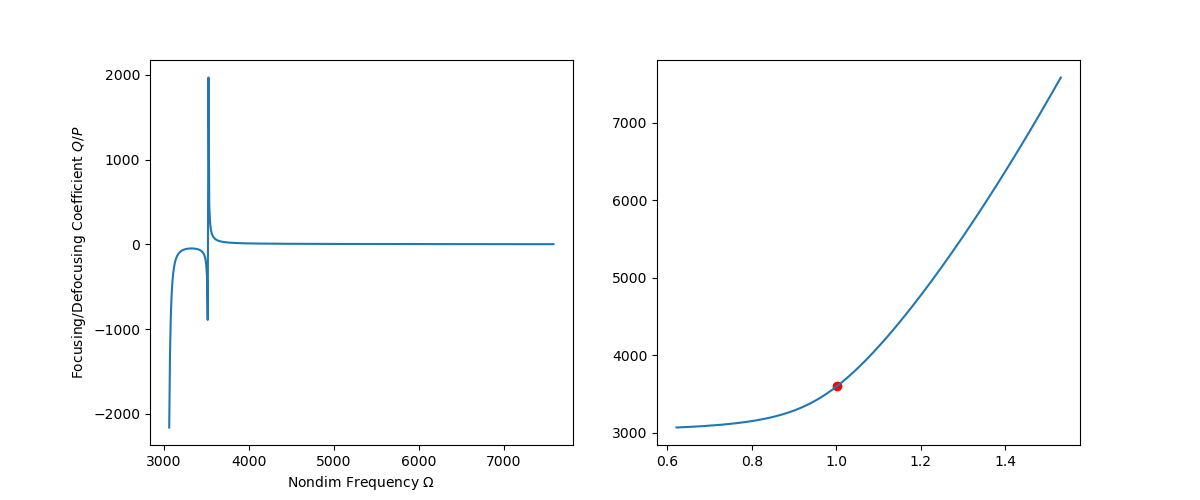

In [118]:

def q_fun_ndim(Omega):
    q4 = (Omega**4 - Omega**2) / ((1 + theta_tilde**2)*Omega**2 - 1)
    return q4**0.25

def q_fun_dim(omega0):
    omega0_ndim = omega0 * ref_scales['t0']
    q0 = q_fun_ndim(omega0_ndim)
    return q0 / ref_scales['x0']

def P_vg_fun_dim(branch):
    if branch == 'acoustic':
        Omega = np.linspace(0, 1/( 1 + theta_tilde**2)**0.5*0.99, 5000)
    elif branch == 'optical':
        Omega = np.linspace(1, 3.0, 5000)
    q = q_fun_ndim(Omega) 
    dOmega_dq = np.gradient(Omega, q)
    d2Omega_dq2 = np.gradient(dOmega_dq, q)
    from scipy.interpolate import interp1d
    dOmega_dq_func = interp1d(Omega, dOmega_dq, kind='cubic', fill_value='extrapolate')
    d2Omega_dq2_func = interp1d(Omega, d2Omega_dq2, kind='cubic', fill_value='extrapolate')
    P = lambda omega0: 0.5 * d2Omega_dq2_func(omega0*ref_scales['t0']) * ref_scales['x0'] **2 / ref_scales['t0']
    v_g = lambda omega0: dOmega_dq_func(omega0*ref_scales['t0']) * ref_scales['x0']  / ref_scales['t0']
    return v_g, P

def P_vg_fun_ndim(branch):
    if branch == 'acoustic':
        Omega = np.linspace(0, 1/( 1 + theta_tilde**2)**0.5*0.99, 5000)
    elif branch == 'optical':
        Omega = np.linspace(1, 3.0, 5000)
    q = q_fun_ndim(Omega) 
    dOmega_dq = np.gradient(Omega, q)
    d2Omega_dq2 = np.gradient(dOmega_dq, q)
    from scipy.interpolate import interp1d
    dOmega_dq_func = interp1d(Omega, dOmega_dq, kind='cubic', fill_value='extrapolate')
    d2Omega_dq2_func = interp1d(Omega, d2Omega_dq2, kind='cubic', fill_value='extrapolate')
    P = lambda omega0: 0.5 * d2Omega_dq2_func(omega0) 
    v_g = lambda omega0: dOmega_dq_func(omega0) 
    return v_g, P


def eigen_vector_ndim(omega0):
    q0 = q_fun_ndim(omega0)
    C_w1 = 1j * theta_tilde * omega0* q0**2  / (-omega0**2 + q0**4)
    C_Lambda1 = 1
    return np.array((C_w1, C_Lambda1))

def F(DT, DX): 
    F_matrix = np.array([
        [DT**2 + DX**4, -theta_tilde*DT*DX**2],
        [theta_tilde*DT*DX**2, DT**2 + 1]
    ])
    return F_matrix

def F_DT(DT, DX): 
    F_matrix = np.array([
        [2*DT, -theta_tilde*DX**2],
        [theta_tilde*DX**2, 2*DT]
    ])
    return F_matrix

def Q_fun_dim(omega0):
    q0 = q_fun_dim(omega0 )
    omega0_ndim = omega0 * ref_scales['t0']
    eig_vec = eigen_vector_ndim(omega0_ndim)
    m_bar = hom_params['m_bar']
    Cp_bar = hom_params['Cp_bar']
    F_matrix = np.array([
        [2*m_bar*omega0, 1j*theta_tilde*q0**2],
        [-1j*theta_tilde*q0**2, 2*Cp_bar*omega0]
    ])
    coeff = - 3 / (hom_params['Lc_bar'] * eig_vec.conj().T @ F_matrix @ eig_vec )
    return coeff




focusing = []
branch = 'optical'
if branch == 'acoustic':
    omega0 = np.linspace(0.01, 0.99/( 1 + theta_tilde**2)**0.5*0.99, 500) /ref_scales['t0'] # acoustic
elif branch == 'optical':
    omega0 = np.linspace(1.01, 2.5, 500) /ref_scales['t0'] # optical
for om0 in omega0:
    v_g, P = P_vg_fun_dim(branch)
    # focusing.append(P(om0) * Q_fun_dim(om0))
    focusing.append(Q_fun_dim(om0)/ P(om0))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(omega0, focusing)
ax[0].set_xlabel('Nondim Frequency $\Omega$')
ax[0].set_ylabel('Focusing/Defocusing Coefficient $Q/P$')
peak_focus = omega0[np.argmax(focusing)]
peak_focus = 3600
print('Peak focusing at nondim frequency Omega = ', peak_focus)
print('ref omega= ', 1/ref_scales['t0']/2/np.pi)
print('Peak focusing at dim frequency f = ', peak_focus  / 2 / np.pi, ' Hz')
print("wave length at peak focusing: ", 2 * np.pi / q_fun_dim(peak_focus ) *1e3, ' mm')
# 1/( 1 + `theta_tilde**2)**0.5
ax[1].plot(q_fun_dim(omega0)*ref_scales['x0'], omega0)
ax[1].scatter(q_fun_dim(peak_focus)*ref_scales['x0'], peak_focus, color='red', label='Peak Focusing')

# q4_fun(0.5)
# q0 = q_fun_ndim(omega0)
# eigen_vector_ndim(omega0).conj().T @ F(-1j * omega0, 1j*q0) @ eigen_vector_ndim(omega0)
# eigen_vector_ndim(omega0).shape
# eigen_vector_ndim(omega0).conj() @ eigen_vector_ndim(omega0)
# F(-1j * omega0, 1j*q0) @ eigen_vector_ndim(omega0)
print('Q at peak focusing: ', Q_fun_dim(peak_focus))
print('P at peak focusing: ', P_vg_fun_dim(branch)[1](peak_focus))

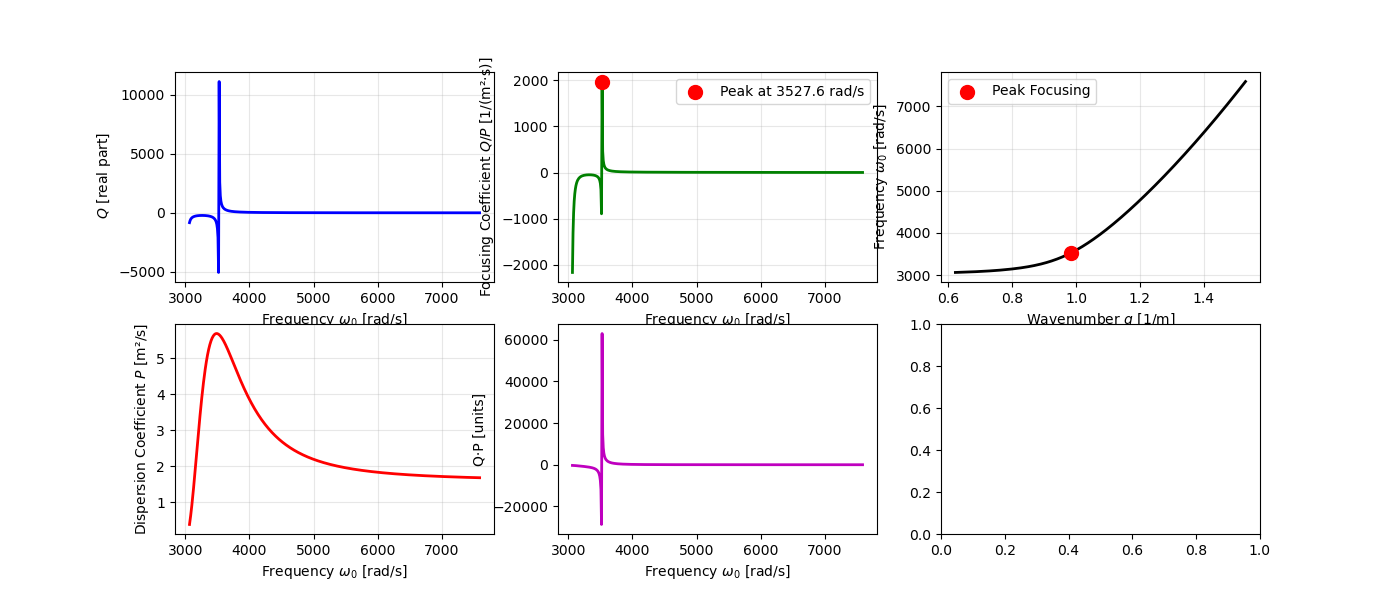

Peak focusing at frequency ω₀ = 3527.5771224748923 rad/s
Peak focusing at frequency f = 561.4313361797634 Hz
Reference frequency: 483.04120272026955 Hz
Wavelength at peak focusing: 142.09699227361259 mm
Q at peak focusing: (11134.099791244449-0j)
P at peak focusing: 5.652480429870991
Q/P at peak focusing: (1969.7723732762338-0j)


In [119]:
# omega0 = np.linspace(0.01, 0.99/(1 + theta_tilde**2)**0.5*0.99, 500) / ref_scales['t0']  # acoustic
# omega0 = np.linspace(0.76, 0.8, 500) + 3524
# Compute Q, P, and focusing coefficient
Q_vals = []
P_vals = []
focusing = []
v_g, P_func = P_vg_fun_dim(branch)
QP_vals = []
for om0 in omega0:
    Q_val = Q_fun_dim(om0)
    P_val = P_func(om0)
    Q_vals.append(Q_val)
    P_vals.append(P_val)
    focusing.append(Q_val / P_val)
    QP_vals.append(Q_val * P_val)

Q_vals = np.array(Q_vals)
P_vals = np.array(P_vals)
focusing = np.array(focusing)
QP_vals = np.array(QP_vals)

# Create figure with 4 subplots
fig, ax = plt.subplots(2, 3, figsize=(14, 6))

# Plot Q coefficient
ax[0, 0].plot(omega0, np.real(Q_vals), 'b-', linewidth=2)
ax[0, 0].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[0, 0].set_ylabel(' $Q$ [real part]')
# ax[0, 0].set_title('Nonlinear Coefficient Q vs Frequency')
ax[0, 0].grid(True, alpha=0.3)

# Plot P coefficient
ax[1, 0].plot(omega0, P_vals, 'r-', linewidth=2)
ax[1, 0].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[1, 0].set_ylabel('Dispersion Coefficient $P$ [m²/s]')
# ax[1, 0].set_title('Dispersion Coefficient P vs Frequency')
ax[1, 0].grid(True, alpha=0.3)
# Plot focusing coefficient Q/P
ax[0, 1].plot(omega0, np.real(focusing), 'g-', linewidth=2)
ax[0, 1].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[0, 1].set_ylabel('Focusing Coefficient $Q/P$ [1/(m²·s)]')
# ax[0, 1].set_title('Focusing Coefficient Q/P vs Frequency')
ax[0, 1].grid(True, alpha=0.3)
peak_focus = omega0[np.argmax(np.real(focusing))]
ax[0, 1].scatter(peak_focus, np.real(focusing[np.argmax(np.real(focusing))]), 
                 color='red', s=100, zorder=5, label=f'Peak at {peak_focus:.1f} rad/s')
ax[0, 1].legend()
# Plot dispersion relation
ax[0, 2].plot(q_fun_dim(omega0)*ref_scales['x0'], omega0, 'k-', linewidth=2)
ax[0, 2].scatter(q_fun_dim(peak_focus)*ref_scales['x0'], peak_focus, 
                 color='red', s=100, zorder=5, label='Peak Focusing')
ax[0, 2].set_xlabel('Wavenumber $q$ [1/m]')
ax[0, 2].set_ylabel('Frequency $\omega_0$ [rad/s]')
# ax[0, 2].set_title('Dispersion Relation')
ax[0, 2].grid(True, alpha=0.3)
ax[0, 2].legend()

ax[1, 1].plot(omega0, QP_vals, 'm-', linewidth=2)
ax[1, 1].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[1, 1].set_ylabel('Q·P [units]')
# plt.tight_layout()
plt.show()

# Print summary statistics
print('Peak focusing at frequency ω₀ =', peak_focus, 'rad/s')
print('Peak focusing at frequency f =', peak_focus / (2 * np.pi), 'Hz')
print('Reference frequency:', 1/ref_scales['t0']/2/np.pi, 'Hz')
print('Wavelength at peak focusing:', 2 * np.pi / q_fun_dim(peak_focus) * 1e3, 'mm')
print('Q at peak focusing:', Q_fun_dim(peak_focus))
print('P at peak focusing:', P_func(peak_focus))
print('Q/P at peak focusing:', Q_fun_dim(peak_focus) / P_func(peak_focus))

vg=  85.19200577229302
At omega0=  3527.5771224748923 sec arag=  (31.38289640294721-0j)


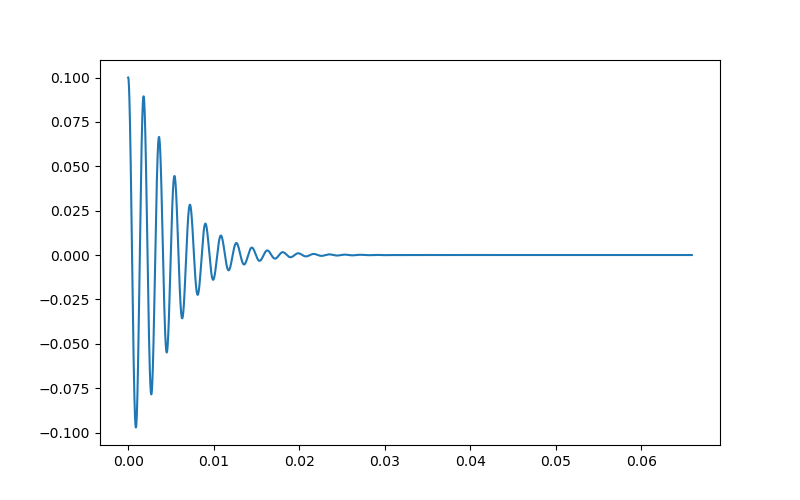

In [159]:
def envelope(omega0, eps_phi):
	vg, P = P_vg_fun_dim(branch)
	Q0 = Q_fun_dim(omega0)
	vg0 = vg(omega0)
	print("vg= ", vg0)
	P0 = P(omega0)
	q0 = q_fun_dim(omega0)
	print('At omega0= ', omega0, 'sec arag= ',np.sqrt(Q0 / (2 * P0)))
	envelope_params = {
		'omega0': omega0,
		'vg0': vg0,
		'P0': P0,
		'Q0': Q0,
		'q0': q0,
		'eps_phi': eps_phi
	}
	def A_func(X, T):
		sech_arg = eps_phi * np.sqrt(Q0 / (2 * P0)) * (X - vg0 * T)
		phase_arg = q0 * X - omega0 * T
		decay = np.exp(1j * 1/2 * eps_phi**2 * Q0  * T )
		A = eps_phi * 1/np.cosh(sech_arg) * np.exp(1j * phase_arg) * decay
		return A
	return A_func, envelope_params

envelope_func, envelope_params = envelope(peak_focus, eps_phi=0.1)
# envelope_func = envelope(2463, eps_phi=0.1)
ncycls = 200
t_eval = np.linspace(0, ncycls * ref_scales['t0'], ncycls*1000)
fig = plt.figure(figsize=(8, 5))
A_t = envelope_func(0, t_eval)
plt.plot(t_eval, np.real(A_t))

# Visualize envelope propagation at multiple time snapshots
# for t in t_eval[::len(t_eval)//2]:
# 	fig = plt.figure(figsize=(8, 5))
# 	A_t = envelope_func(x_eval, t)
# 	plt.plot(x_eval, np.real(A_t), label=f't={t/ref_scales["t0"]:0.1f} t0')
# 	plt.xlabel('x [mm]')
# 	plt.ylabel('Re{A(x,t)}')
# 	plt.title(f'Envelope at time t {t/ref_scales["t0"]:0.1f} t0')
# 	plt.legend()
# 	# plt.ylim([-0.02, 0.02])
# 	# plt.show()
# 	# clear_output(wait=True)


length of t_eval:  200000
vg=  85.19200577229302
At omega0=  3527.5771224748923 sec arag=  (31.38289640294721-0j)


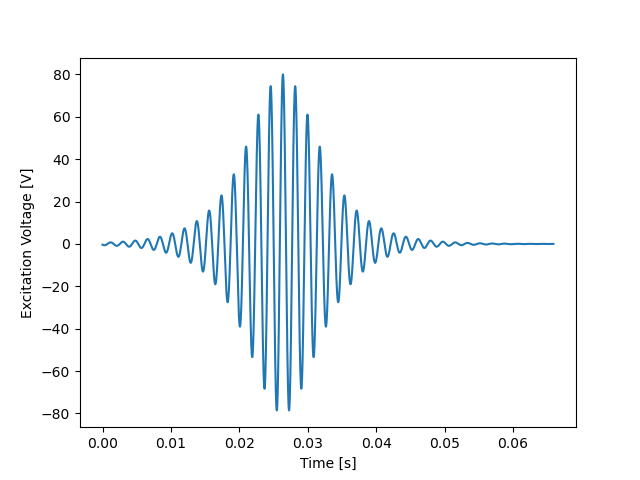

In [161]:
print("length of t_eval: ", len(t_eval) )
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
envelope_func, envelope_params = envelope(peak_focus, eps_phi=0.08)

def make_v_exc():
    flux_linkage = envelope_func(0,
                                  t_eval-0.4*t_eval[-1]
                                  )*1000
    # voltage = cumulative_trapezoid(np.real(flux_linkage), t_eval, initial=0) 
    voltage = np.real(flux_linkage)
    v = interp1d(t_eval, voltage, kind='cubic', fill_value='extrapolate')
    return v
v_exc = make_v_exc()



plt.figure()
plt.plot(t_eval, v_exc(t_eval), '-' )
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.show()


In [162]:
ode = fe.build_ode_system(
    j_exc=j_exc,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=v_exc
)
ndof = ode.M.shape[0]

x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)
result = FE1.solve_newmark(
	ode=ode,
	dt=t_eval[1]-t_eval[0],
	t_end=t_eval[-1],
	beta=0.25,
	gamma=0.5,
	newton_tol=1e-8,
	newton_maxiter=8,
	x0=x0,
	x_dot0=x_dot0
	)

# Extract results from dictionary
t = result['t']
w = result['u']                # mechanical displacement
w_dot = result['u_dot']        # mechanical velocity
w_ddot = result['u_ddot']      # mechanical acceleration
q = result['q']                # electrical charge
v = result['v']                # voltage
spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)


Newmark Integration: 100%|██████████| 199999/199999 [4:31:17<00:00, 12.29step/s]  


X shape: (200000,) Y shape: (200000, 601) freq shape: (200000,) veloc shape: (200000, 601)


In [163]:
result['envelope_params'] = envelope_params  # envelope parameters
result['K_c'] = K_c
result['K_i'] = K_i
result['K_p'] = K_p


In [164]:
import pickle
from pathlib import Path
result['envelope_params'] = envelope_params  # envelope parameters
# Create results directory if it doesn't exist
results_dir = Path('./results')
results_dir.mkdir(parents=True, exist_ok=True)


# Save the entire result dictionary
with open(results_dir / 'soliton_FE_results.pkl', 'wb') as f:
    pickle.dump(result, f)

# print(f"Results saved to {results_dir / 'soliton_FE_results.pkl'}")
# np.savez_compressed(
#     results_dir / 'soliton_FE_results.npz',
#     **result, allow_pickle=True
# )

In [ ]:
with open(results_dir / 'soliton_FE_results.pkl', 'rb') as f:
    result = pickle.load(f)
    t = result['t']
    w = result['u']                # mechanical displacement
    w_dot = result['u_dot']        # mechanical velocity
    w_ddot = result['u_ddot']      # mechanical acceleration
    q = result['q']                # electrical charge
    v = result['v']                # voltage
    spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)

# with np.load(results_dir / 'soliton_FE_results.npz', allow_pickle=True) as result:
#     t = result['t']
#     w = result['u']                # mechanical displacement
#     w_dot = result['u_dot']        # mechanical velocity
#     w_ddot = result['u_ddot']      # mechanical acceleration
#     q = result['q']                # electrical charge
#     v = result['v']                # voltage
#     spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
#     for k in result.files:
#         print(k, result[k].shape, result[k].dtype)

In [ ]:
result['envelope_params']

{'omega0': np.float64(1828.8401279107006),
 'vg0': np.float64(92.88554071410248),
 'P0': np.float64(-0.0007633161141267041),
 'Q0': np.complex128(-1.8616510383278682+0j),
 'q0': np.float64(35.48086257502789),
 'eps_phi': 0.05}

(200000, 601)


Text(0, 0.5, 'Velocity ')

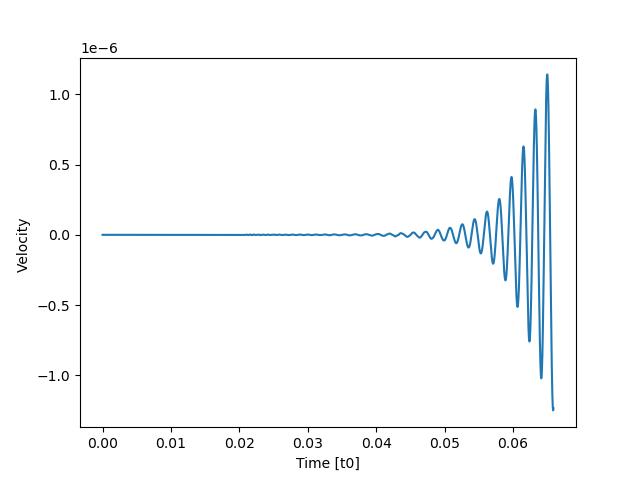

In [165]:
print(w_dot.shape)
plt.figure()
plt.plot(t, w[:, 200] , '-' )
plt.xlabel('Time [t0]')
plt.ylabel('Velocity ')

Saving frame 900/900Saved animation to ./anim/beam_displacement3.mp4


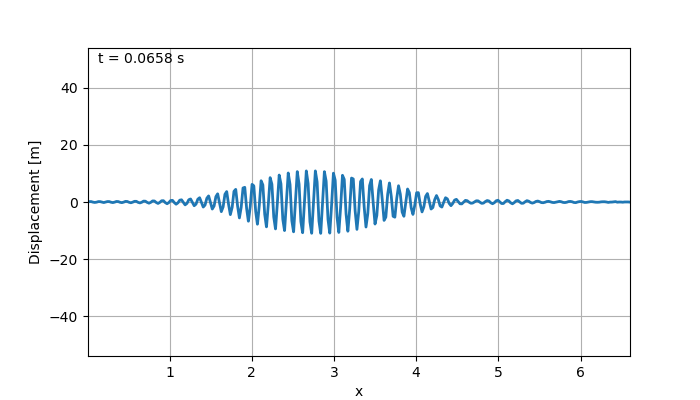

In [170]:
import importlib
from Modeling.models import plotting
importlib.reload(plotting)
temporal_slice = slice(20000, -1)
plotting.animate_field_1d(
	t=t_eval[	temporal_slice],
	u=w_dot[temporal_slice,  :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_displacement3.mp4",
	scale=2000,
    stride=200,
	ylabel="Displacement [m]",
    fps=150
)


In [ ]:
import subprocess
subprocess.run(["ffmpeg", "-version"], check=True)


CompletedProcess(args=['ffmpeg', '-version'], returncode=0)